# 음성정보처리 기본 표현
## Overlap Add와 주파수 특성 및 표현
* 2026-10-01 수업

In [2]:
%pip install librosa matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import scipy.signal as sps
import matplotlib as mpl
import matplotlib.pyplot as plt

import librosa
import librosa.display
from IPython.display import Audio, display

print("librosa 버전:", librosa.__version__)
print("numpy  버전:", np.__version__)

# ── 그래프 한글 폰트 설정 (운영체제에 맞는 것이 자동 선택됩니다) ──────────
# for font in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
#    if font in {f.name for f in mpl.font_manager.fontManager.ttflist}:
#        mpl.rcParams["font.family"] = font
#        break
mpl.rcParams["font.family"] = ["Malgun Gothic","DejaVu Sans"]
mpl.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지
mpl.rcParams["figure.figsize"] = (11, 3.5)
mpl.rcParams["figure.max_open_warning"] = 0
print("사용 폰트:", mpl.rcParams["font.family"])

librosa 버전: 1.0.0
numpy  버전: 2.5.3
사용 폰트: ['Malgun Gothic', 'DejaVu Sans']


In [4]:
# ── 오늘 사용할 음성 파일 ─────────────────────────────────────────────
# 방법 A: librosa 내장 예제 (영어 낭독 음성, 인터넷 필요)
# 방법 B: 직접 녹음한 wav 파일 경로를 AUDIO_PATH 에 적기  (권장! 자기 목소리가 제일 재미있습니다)
# 방법 C: 인터넷이 안 되면 맨 아래 [부록 A]의 합성 음성 코드를 먼저 실행

AUDIO_PATH = None          # 예: AUDIO_PATH = "my_voice.wav"
SR = 16000                 # 광대역 음성 표준

if AUDIO_PATH:
    y, sr = librosa.load(AUDIO_PATH, sr=SR, mono=True)
else:
    y, sr = librosa.load(librosa.example("libri1"), sr=SR, mono=True)

y = y[:int(4.0 * sr)]      # 너무 길면 앞 4초만 사용

print("y 타입      :", type(y))
print("y shape     :", y.shape, "  ← 샘플 개수")
print("y dtype     :", y.dtype, " ← 실수(float32), 보통 -1.0 ~ +1.0 범위")
print("sr          :", sr, "Hz")
print("길이        : %.2f 초" % librosa.get_duration(y=y, sr=sr))
print("샘플 수 검산: %d x %.2f = %.0f" % (sr, len(y)/sr, len(y)))
print("최대 진폭   : %.3f" % np.max(np.abs(y)))
print("\ny 의 앞 10개 값:", np.round(y[:10], 4))

y 타입      : <class 'numpy.ndarray'>
y shape     : (64000,)   ← 샘플 개수
y dtype     : float32  ← 실수(float32), 보통 -1.0 ~ +1.0 범위
sr          : 16000 Hz
길이        : 4.00 초
샘플 수 검산: 16000 x 4.00 = 64000
최대 진폭   : 0.779

y 의 앞 10개 값: [0.0003 0.0003 0.0002 0.0002 0.0001 0.0002 0.0001 0.0002 0.0001 0.0002]


In [5]:
# 들어보기 (Jupyter 전용 플레이어)
display(Audio(data=y, rate=sr))

frames.shape = (400, 398)  → (윈도우 길이, 프레임 개수)
공식으로 계산한 프레임 개수: 398


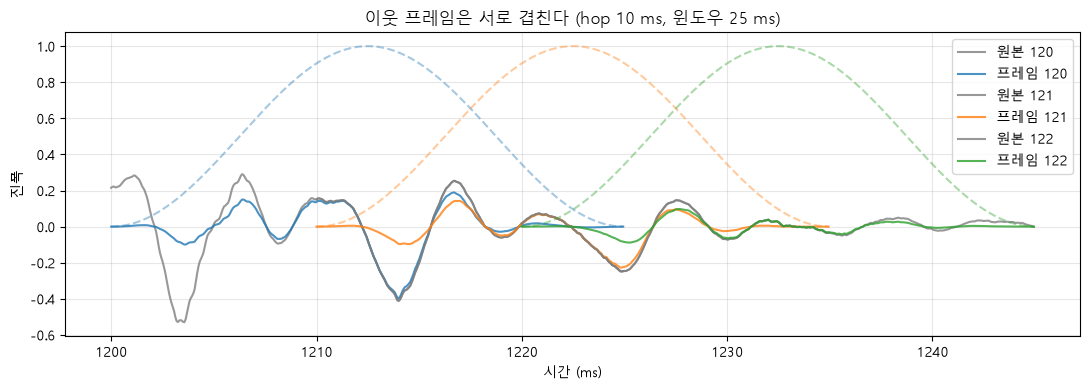

In [9]:
# 이 노트북 전체에서 쓸 분석 파라미터 (교재 2.4.3 권장값)
FRAME_LEN = 400    # 25 ms  @16 kHz
HOP_LEN   = 160    # 10 ms  @16 kHz  → 오버랩 60%
N_FFT     = 512    # 400을 담을 수 있는 2의 거듭제곱 (나머지는 0으로 채움 = 영 확장)

frames = librosa.util.frame(y, frame_length=FRAME_LEN, hop_length=HOP_LEN)
print("frames.shape =", frames.shape, " → (윈도우 길이, 프레임 개수)")

# 교재 2.2.1의 길이 공식과 대조해 봅시다
n_frames = 1 + (len(y) - FRAME_LEN) // HOP_LEN
print("공식으로 계산한 프레임 개수:", n_frames)

w = sps.get_window("hann", FRAME_LEN, fftbins=True)
frames_win = frames * w[:, np.newaxis]     # 각 열(프레임)에 윈도우를 곱함 (브로드캐스팅)

# 이웃한 세 프레임이 어떻게 겹치는지 그림으로
idx = 120
fig, ax = plt.subplots(figsize=(11, 4))
for k, color in zip([idx, idx+1, idx+2], ["C0", "C1", "C2"]):
    t0 = k * HOP_LEN / sr * 1000
    t  = t0 + np.arange(FRAME_LEN)/sr*1000
    ax.plot(t, frames[:, k] + 0, color="C7", alpha=.8, label=f"원본 {k}")
    ax.plot(t, frames_win[:, k] + 0, color=color, alpha=.8, label=f"프레임 {k}")
    ax.plot(t, w, color=color, ls="--", alpha=.4)
ax.set(title="이웃 프레임은 서로 겹친다 (hop 10 ms, 윈도우 25 ms)",
       xlabel="시간 (ms)", ylabel="진폭")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## overlap add에 의해서 원본을 복원
### STFT with windowing -> ISTFT 

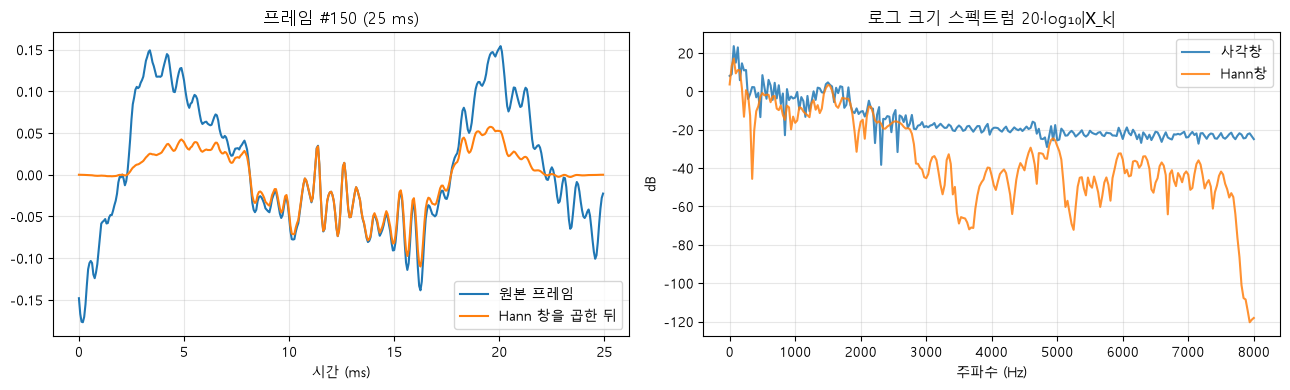

In [10]:
frame_idx = 150                                  # ← 유성음 구간이 나올 때까지 바꿔 보세요
x_frame = frames[:, frame_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(FRAME_LEN)/sr*1000, x_frame, label="원본 프레임")
axes[0].plot(np.arange(FRAME_LEN)/sr*1000, x_frame*w, label="Hann 창을 곱한 뒤")
axes[0].set(title=f"프레임 #{frame_idx} (25 ms)", xlabel="시간 (ms)"); axes[0].legend(); axes[0].grid(alpha=.3)

freqs = np.fft.rfftfreq(N_FFT, 1/sr)
for label, xx in [("사각창", x_frame), ("Hann창", x_frame*w)]:
    X = np.abs(np.fft.rfft(xx, n=N_FFT))
    axes[1].plot(freqs, 20*np.log10(X + 1e-10), label=label, alpha=.85)
axes[1].set(title="로그 크기 스펙트럼 20·log₁₀|X_k|", xlabel="주파수 (Hz)", ylabel="dB")
axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

Princen-Bradley 조건 w²_n + w²_{n+L/2} = 1 인가?
  최소값 = 1.000000,  최대값 = 1.000000


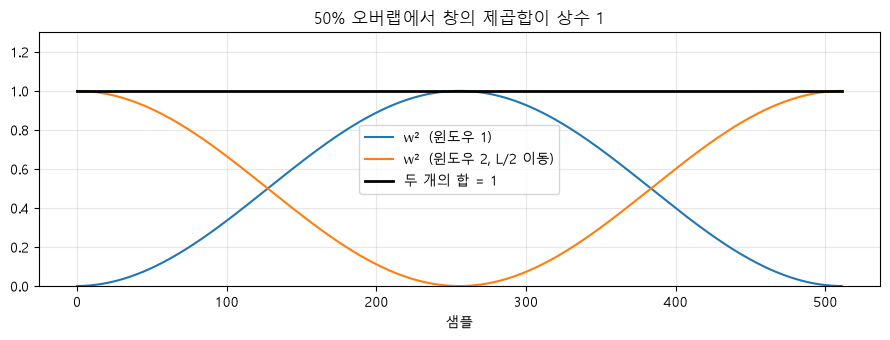

In [11]:
# 반사인 창은 50% 오버랩에서 제곱합이 1이 된다 → 완전 재구성
L2 = 512
w_hs = np.sin(np.pi * (np.arange(L2) + 0.5) / L2)     # 반사인 창
check = w_hs[:L2//2]**2 + w_hs[L2//2:]**2             # w²_n + w²_{n+L/2}

print("Princen-Bradley 조건 w²_n + w²_{n+L/2} = 1 인가?")
print("  최소값 = %.6f,  최대값 = %.6f" % (check.min(), check.max()))

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(w_hs**2, label="w²  (윈도우 1)")
ax.plot(np.roll(w_hs**2, L2//2), label="w²  (윈도우 2, L/2 이동)")
ax.plot(w_hs**2 + np.roll(w_hs**2, L2//2), "k", lw=2, label="두 개의 합 = 1")
ax.set(title="50% 오버랩에서 창의 제곱합이 상수 1", xlabel="샘플", ylim=(0, 1.3))
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

최대 오차      : 1.192e-07
오차 에너지 비 : -141.28 dB


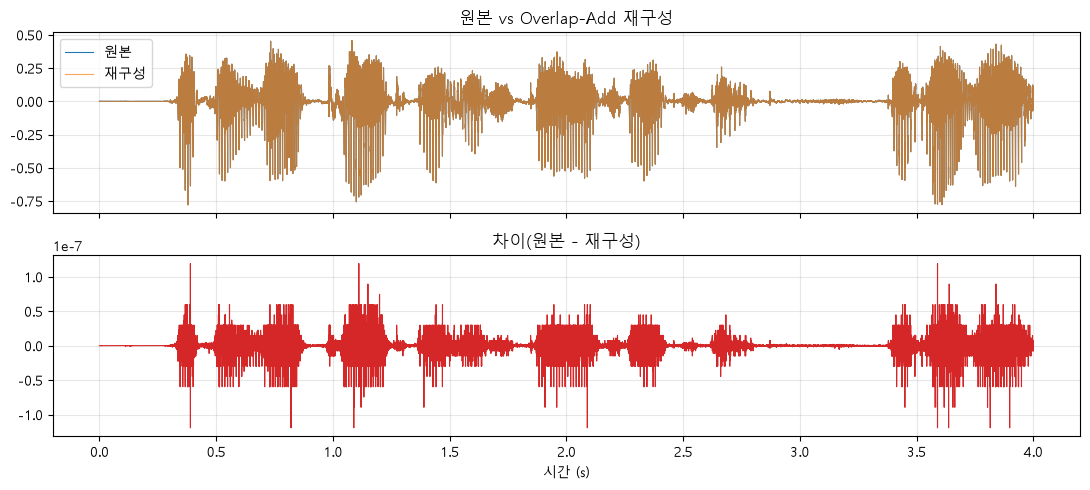

In [17]:
# librosa로 STFT → 아무 처리도 안 하고 → ISTFT (내부가 바로 Overlap-Add 입니다)
D      = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LEN, win_length=FRAME_LEN, window="hann")
y_rec  = librosa.istft(D, n_fft=N_FFT, hop_length=HOP_LEN, win_length=FRAME_LEN, length=len(y))

err = y - y_rec
print("최대 오차      : %.3e" % np.max(np.abs(err)))
print("오차 에너지 비 : %.2f dB" % (10*np.log10(np.sum(err**2)/np.sum(y**2) + 1e-30)))

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(np.arange(len(y))/sr, y,     label="원본",     lw=.8)
axes[0].plot(np.arange(len(y))/sr, y_rec, label="재구성",   lw=.8, alpha=.7)
axes[0].legend(); axes[0].set(title="원본 vs Overlap-Add 재구성")
axes[1].plot(np.arange(len(y))/sr, err, color="C3", lw=.8)
axes[1].set(title="차이(원본 - 재구성)", xlabel="시간 (s)")
for a in axes: a.grid(alpha=.3)
plt.tight_layout(); plt.show()


In [15]:
display(Audio(data=y_rec, rate=24000))
display(Audio(data=y_rec, rate=16000))
display(Audio(data=y_rec, rate=8000))

## STFT와 스펙트럼, 스펙트로그램 
 - 스펙트럼 : 특정 시간에서의 주파수 특성
 - 스펙트로그램 : 시간에 변화에 따른 주파수 특성(Frame 의 스펙트럼 변화량)

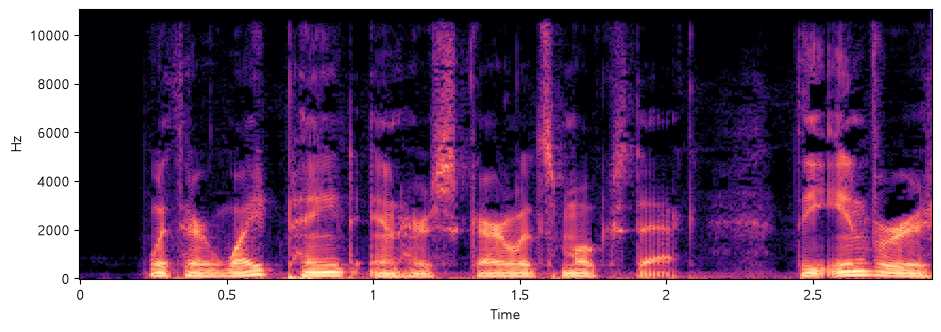

In [21]:
D    = librosa.stft(y, n_fft=512, hop_length=160, win_length=400)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
librosa.display.specshow(S_db, hop_length=160, x_axis="time", y_axis="hz")

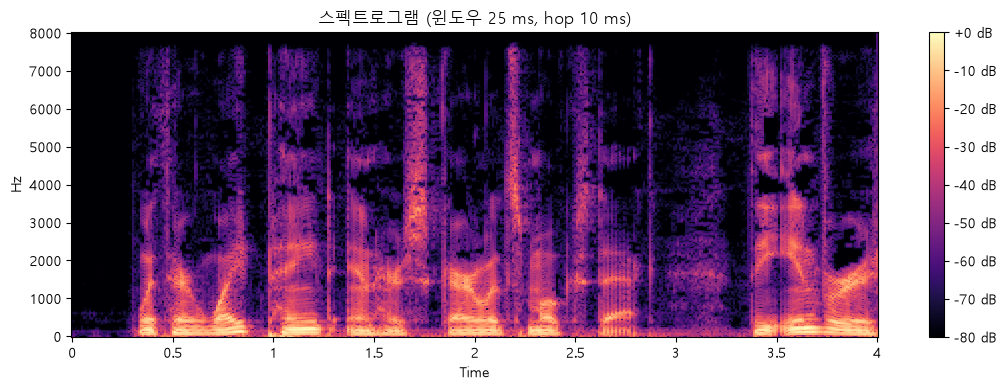

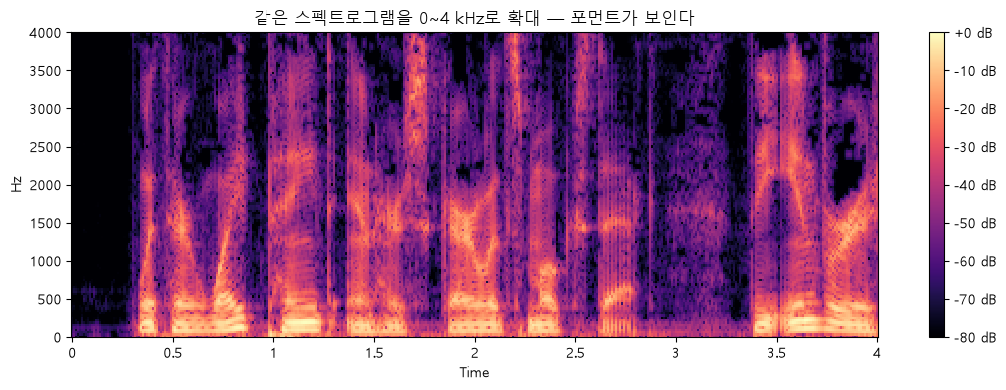

In [22]:
# 앞으로 계속 쓸 간단한 헬퍼
def show_spec(D_complex, sr, hop_length, title, y_axis="hz", ax=None, fmax=None):
    S_db = librosa.amplitude_to_db(np.abs(D_complex), ref=np.max)
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(11, 4))
    img = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length,
                                   x_axis="time", y_axis=y_axis, ax=ax, cmap="magma")
    if fmax:
        ax.set_ylim(0, fmax)
    ax.set(title=title)
    if created:
        ax.figure.colorbar(img, ax=ax, format="%+2.0f dB")
        plt.tight_layout(); plt.show()
    return img


show_spec(D, sr, HOP_LEN, "스펙트로그램 (윈도우 25 ms, hop 10 ms)")
show_spec(D, sr, HOP_LEN, "같은 스펙트로그램을 0~4 kHz로 확대 — 포먼트가 보인다", fmax=4000)

Dx shape: (65, 2001)
Dx shape: (257, 401)
Dx shape: (513, 134)


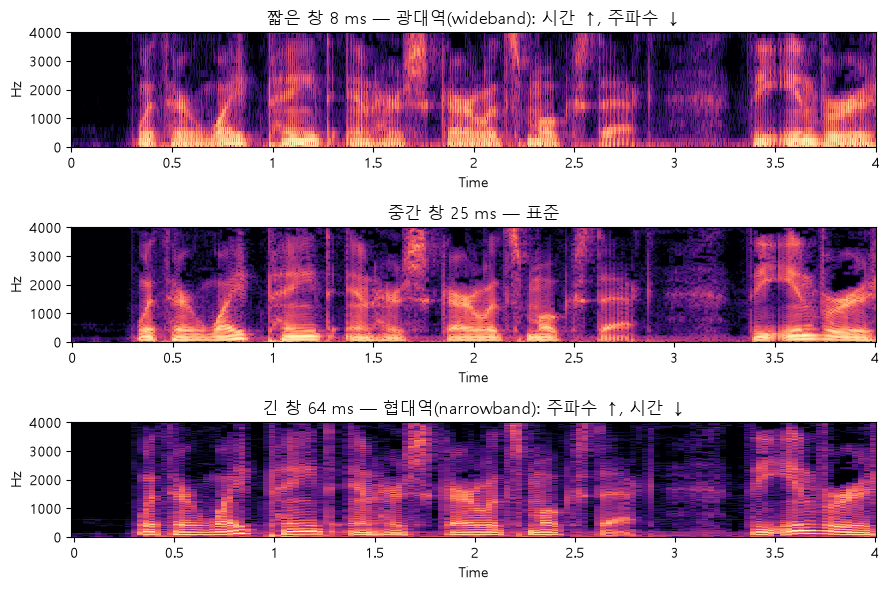

In [26]:
configs = [
    (128,  32, "짧은 창 8 ms — 광대역(wideband): 시간 ↑, 주파수 ↓"),
    (400, 160, "중간 창 25 ms — 표준"),
    (1024, 480, "긴 창 64 ms — 협대역(narrowband): 주파수 ↑, 시간 ↓"),
]

fig, axes = plt.subplots(3, 1, figsize=(9, 6))
for (wl, hl, title), ax in zip(configs, axes):
    nfft = int(2 ** np.ceil(np.log2(wl)))
    Dx = librosa.stft(y, n_fft=nfft, hop_length=hl, win_length=wl, window="hann")
    show_spec(Dx, sr, hl, title, ax=ax, fmax=4000)
    print(f"Dx shape: {Dx.shape}")
plt.tight_layout(); plt.show()

## 유성음과 무성음 비교

유성음 후보 프레임 #372  (t=3.72s, ZCR=0.013)
무성음 후보 프레임 #219 (t=2.19s, ZCR=0.502)


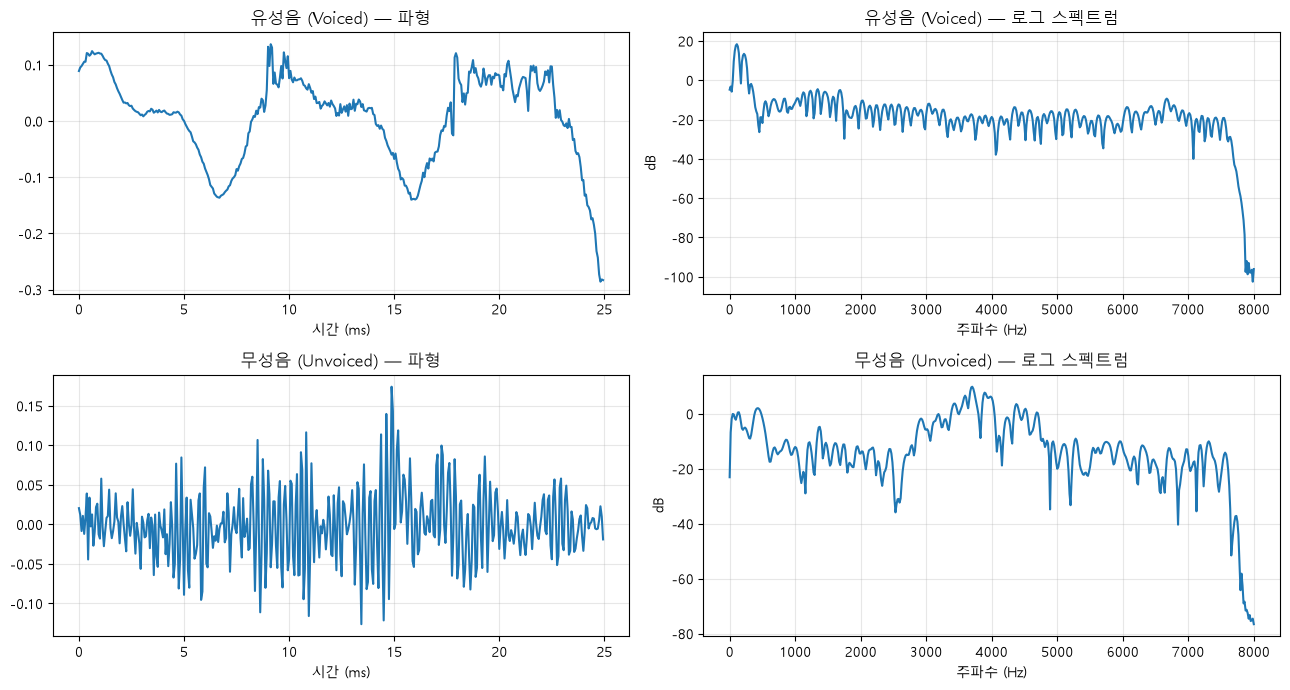

In [28]:
rms = librosa.feature.rms(y=y, frame_length=FRAME_LEN, hop_length=HOP_LEN)[0]
zcr = librosa.feature.zero_crossing_rate(y, frame_length=FRAME_LEN, hop_length=HOP_LEN)[0]

loud = rms > np.percentile(rms, 30)                       # 소리가 충분히 큰 프레임만 후보
voiced_idx   = int(np.argmax(np.where(loud, -zcr, -9e9))) # 큰데 ZCR이 낮다 → 유성음
unvoiced_idx = int(np.argmax(np.where(loud,  zcr, -9e9))) # 큰데 ZCR이 높다 → 무성음
print(f"유성음 후보 프레임 #{voiced_idx}  (t={voiced_idx*HOP_LEN/sr:.2f}s, ZCR={zcr[voiced_idx]:.3f})")
print(f"무성음 후보 프레임 #{unvoiced_idx} (t={unvoiced_idx*HOP_LEN/sr:.2f}s, ZCR={zcr[unvoiced_idx]:.3f})")

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for row, (name, idx) in enumerate([("유성음 (Voiced)", voiced_idx),
                                   ("무성음 (Unvoiced)", unvoiced_idx)]):
    seg = y[idx*HOP_LEN: idx*HOP_LEN + FRAME_LEN]
    axes[row, 0].plot(np.arange(len(seg))/sr*1000, seg)
    axes[row, 0].set(title=f"{name} — 파형", xlabel="시간 (ms)")
    spec = 20*np.log10(np.abs(np.fft.rfft(seg*sps.get_window('hann', len(seg)), n=1024)) + 1e-10)
    axes[row, 1].plot(np.fft.rfftfreq(1024, 1/sr), spec)
    axes[row, 1].set(title=f"{name} — 로그 스펙트럼", xlabel="주파수 (Hz)", ylabel="dB")
for a in axes.ravel(): a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [29]:
for row, (name, idx) in enumerate([("유성음 (Voiced)", voiced_idx),
                                   ("무성음 (Unvoiced)", unvoiced_idx)]):
    seg = y[idx*HOP_LEN: idx*HOP_LEN + FRAME_LEN]
    print(name)
    display(Audio(data=seg, rate=16000))


유성음 (Voiced)


무성음 (Unvoiced)
